In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**1. Load the dataset and Display first 15 rows**

In [41]:
data = pd.read_csv("/content/1776250375-P2-Healthcare Analytics for Doctor Visits.csv")
print(data.head(15))

    Unnamed: 0  visits  gender   age  income  illness  reduced  health  \
0            1       1  female  0.19    0.55        1        4       1   
1            2       1  female  0.19    0.45        1        2       1   
2            3       1    male  0.19    0.90        3        0       0   
3            4       1    male  0.19    0.15        1        0       0   
4            5       1    male  0.19    0.45        2        5       1   
5            6       1  female  0.19    0.35        5        1       9   
6            7       1  female  0.19    0.55        4        0       2   
7            8       1  female  0.19    0.15        3        0       6   
8            9       1  female  0.19    0.65        2        0       5   
9           10       1    male  0.19    0.15        1        0       0   
10          11       1    male  0.19    0.45        1        0       0   
11          12       1    male  0.19    0.25        2        0       2   
12          13       2    male  0.19  

**2. Display complete information about the columns of the database such as column name, Count, Data type and oveoll memory usage.**

In [42]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB
None


**3. Find out the total no: of people based on their count of illeness**

In [43]:
data["illness"].value_counts()

,count
illness,
1,1638
0,1554
2,946
3,542
4,274
5,236


**4. Visualize and analyse the maximum, minimum and medium income**

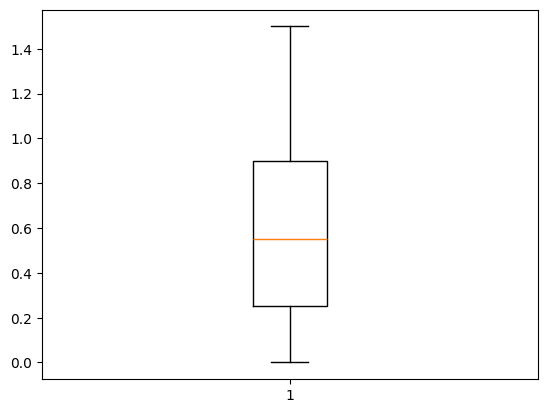

In [44]:
y = list(data.income)
plt.boxplot(y)
plt.show()

**5. Find out the no of days of reduced activity of male and female seperatly due to illeness**

In [45]:
data.groupby('gender')['reduced'].sum()

,reduced
gender,
female,2636
male,1837


In [46]:
data.groupby('gender')['reduced'].mean()

,reduced
gender,
female,0.975574
male,0.738344


**6. Visualize is there is any missing values in the dataset basedd on a heat map**

<Axes: >

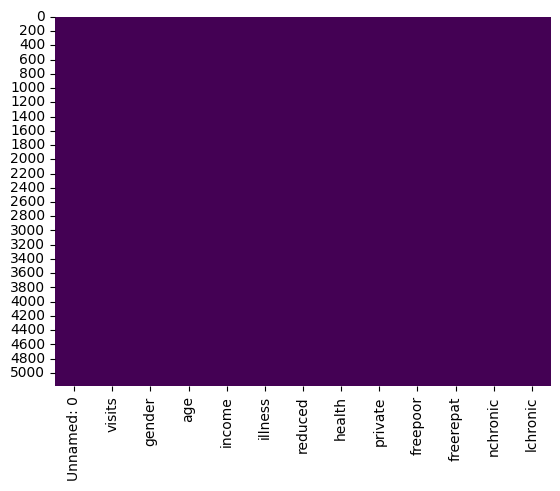

In [47]:
#Missing values

sns.heatmap(data.isnull(),cbar=False, cmap="viridis")

**7. Find out the Correlation between variables in the given dataset correlation betweeen different variables**

<Axes: >

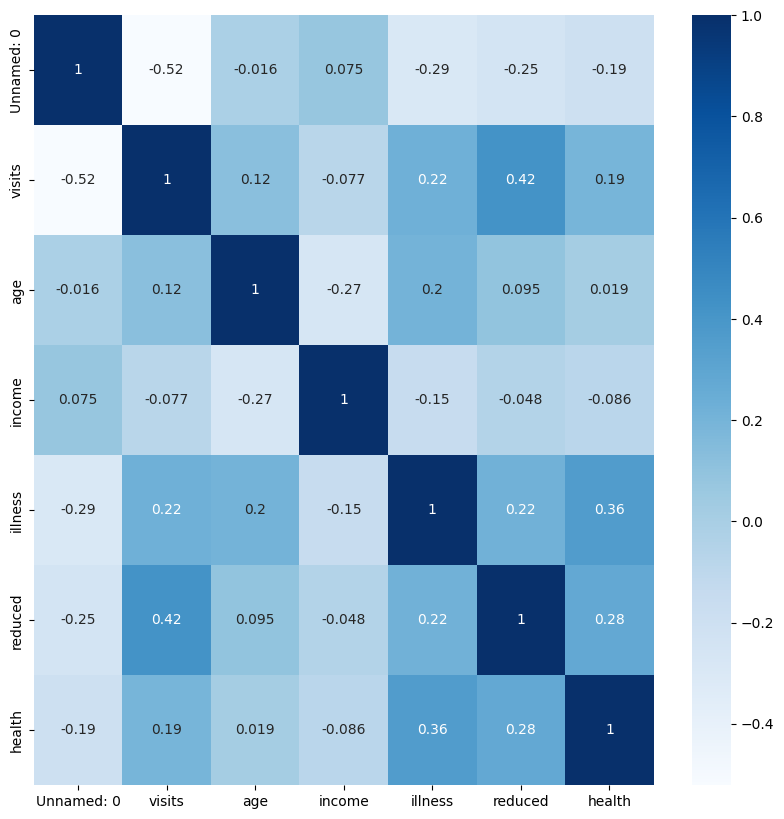

In [48]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(numeric_only=True),cbar=True,annot=True,cmap='Blues')

**8. Analyse how the income of a patient affects the no of visits to the hospital**


Text(0, 0.5, 'visits')

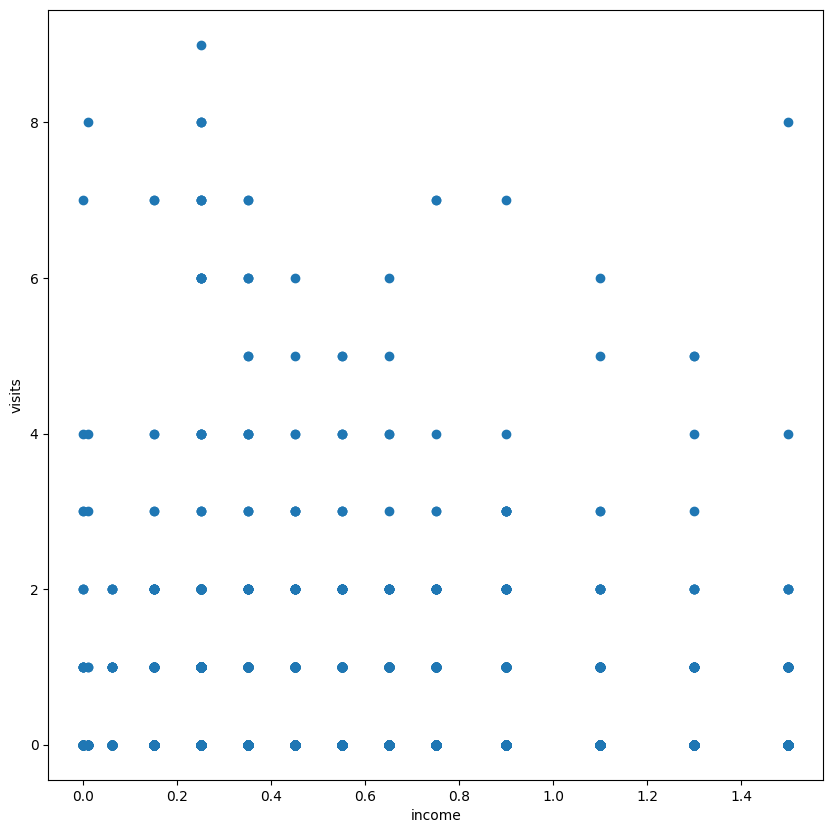

In [49]:
#relation between income and visits
plt.figure(figsize=(10,10))
plt.scatter(x='income', y='visits', data=data)
plt.xlabel('income')
plt.ylabel('visits')

**9. Count and visualize the number of males and females affected by illness**

<Axes: xlabel='gender', ylabel='Count'>

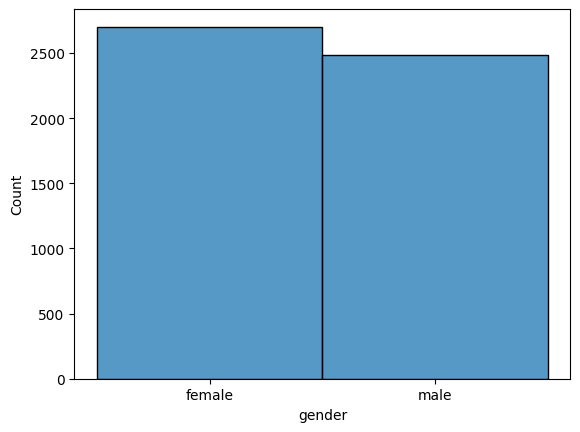

In [50]:
# No: of male and female affected by illness
sns.histplot(data.gender,bins=2)

**10. Visualize the percentage of people getting govt health insurance due to low income, due to old age and also the percentage of people having private health insurance**

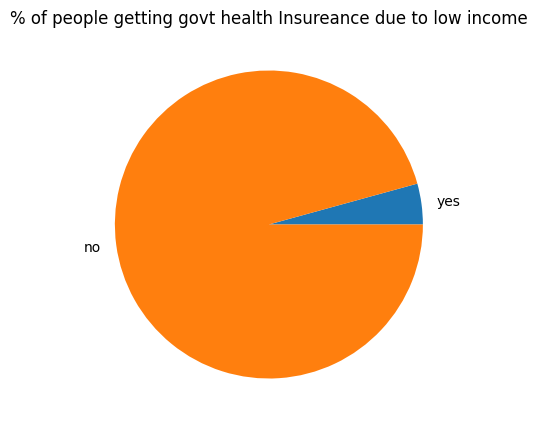

In [51]:
# % of people getting govt Insurance due to low income

label = ['yes','no']
Y = data[data['freepoor']=='yes']
N = data[data['freepoor']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people getting govt health Insureance due to low income")
plt.show()

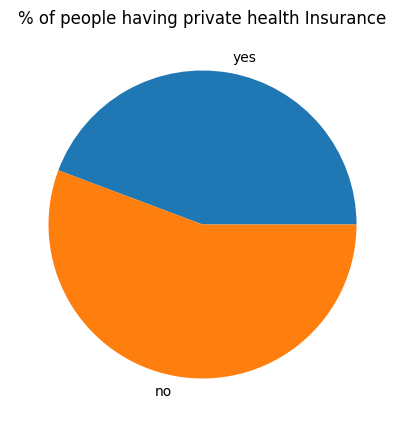

In [52]:
# % of people having private Insurance
Y = data[data['private']=='yes']
N = data[data['private']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people having private health Insurance")
plt.show()

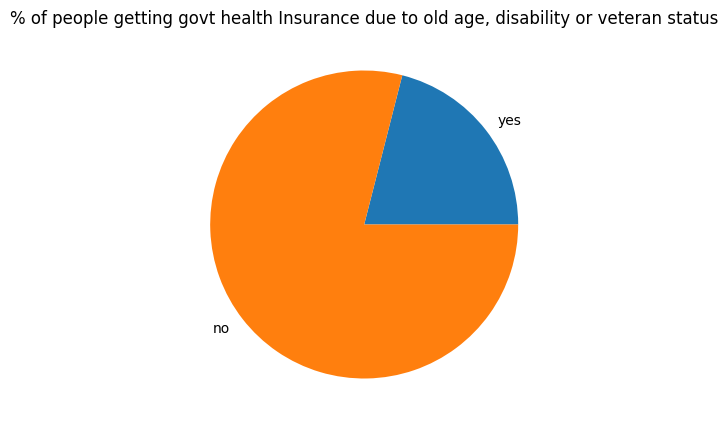

In [53]:
# % of people getting govt Insurance due to old age, disability or veteran status
Y = data[data['freerepat']=='yes']
N = data[data['freerepat']=='no']
x = [Y.shape[0],N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x,labels=label)
plt.title("% of people getting govt health Insurance due to old age, disability or veteran status")
plt.show()


**11. Plot a horizontal bar chart to analyze the reduced days of activity due to iilneess based on gender
bold text bold text**

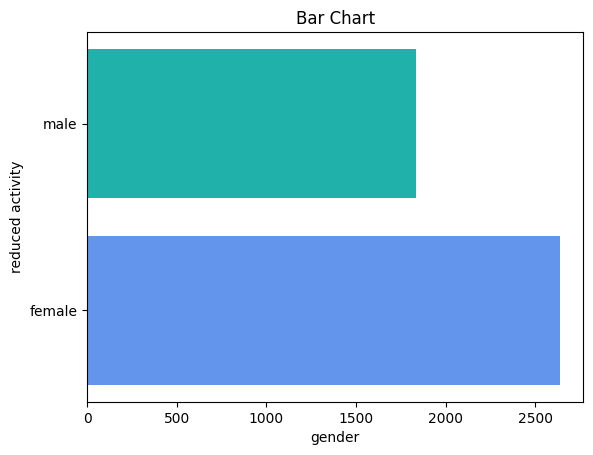

In [54]:
db = data.groupby('gender')['reduced'].sum().to_frame().reset_index()
#Creating the bar chart
plt.barh(db['gender'],db['reduced'],color = ['cornflowerblue','lightseagreen'])
#Adding the aesthetics
plt.title('Bar Chart')
plt.xlabel('gender')
plt.ylabel('reduced activity')
#show the plot
plt.show()